In [1]:
import os
import json
import re
import requests
import textwrap
import os
from typing import Dict, TypedDict,List
from langchain_core.messages import HumanMessage, SystemMessage
from typing import Any
from langchain_groq import ChatGroq
from langchain.schema import BaseMessage
from langgraph.graph import StateGraph, END

# Agentic flow in a Jupyter cell: greet -> generate content (attempt Groq) -> render PDF with PyMuPDF
import fitz  # PyMuPDF


In [2]:
def slugify(s: str) -> str:
    s = re.sub(r"[^\w\s-]", "", s).strip().lower()
    return re.sub(r"[-\s]+", "-", s)

In [3]:
# Set up the Groq LLM
llm = ChatGroq(
        model_name="llama-3.3-70b-versatile",
        temperature=0.1,
        model_kwargs={"top_p": 0.5, "seed": 1337}
    )
# Define our state structure


class State(TypedDict):
    messages: List[BaseMessage]
    next_step: str

workflow = StateGraph(State)    

In [ ]:
# Node implementations use the provided State TypedDict and the existing `llm`, `workflow`, `fitz`, `slugify`, and `END`.
# We'll define node functions and attempt to register them with the existing StateGraph (`workflow`).
# Additionally we provide a small runner that will execute the nodes by name (in case the StateGraph registration API differs).

def _call_llm(messages: list[BaseMessage]) -> str:
    """Call the ChatGroq LLM with a small compatibility wrapper and return the raw text response."""
    # Try the LangChain-style generate API first
    try:
        result = llm.generate([messages])
        # LangChain-style Generation result extraction
        text = result.generations[0][0].text  # type: ignore
        return text
    except Exception:
        pass

    # Try call-like interfaces
    try:
        resp = llm(messages=messages)  # type: ignore
        # Many chat wrappers return an object with .content or .text or str()
        if hasattr(resp, "content"):
            return resp.content  # type: ignore
        if hasattr(resp, "text"):
            return resp.text  # type: ignore
        return str(resp)
    except Exception:
        pass

    # As a last resort try direct call
    resp = llm(messages)  # type: ignore
    return str(resp)

# 1) Greet node: ask the user for a topic and store it in state.messages as a HumanMessage; advance next_step -> "generate"
def greet_node(state: State) -> State:
    state_messages = state.get("messages", [])
    prompt = "Hello! What topic would you like me to write about for the PDF?"
    # interactive: get topic from notebook user
    topic = input(prompt + " ")
    # add a system context + the user's topic as a HumanMessage
    state_messages.append(SystemMessage(content="You are a helpful assistant that outputs JSON suitable for PDF rendering."))
    state_messages.append(HumanMessage(content=f"Topic: {topic}"))
    state["messages"] = state_messages
    state["next_step"] = "generate"
    # store the topic for later convenience
    state["topic"] = topic  # type: ignore
    return state

# 2) Generate node: use the topic to ask the LLM to produce JSON describing the PDF content (paragraphs + simple style)
def generate_node(state: State) -> State:
    # find the HumanMessage containing the topic (or use stored topic)
    topic = state.get("topic")
    if not topic:
        # fallback: try to extract from messages
        topic = None
        for m in state.get("messages", []):
            if isinstance(m, HumanMessage) and m.content.lower().startswith("topic:"):
                topic = m.content.split(":", 1)[1].strip()
                break
    if not topic:
        raise RuntimeError("No topic provided in state.")

    # Prompt the LLM to emit a JSON structure. The expected output is:
    # { "document": [ { "text": "...", "font": "Times-Roman", "font_size": 12, "align": "left" }, ... ] }
    generation_instructions = textwrap.dedent(
        f"""
        Produce a JSON object with a single key "document" whose value is a list of paragraph objects.
        Each paragraph object must contain:
          - "text": the paragraph text (string)
          - "font": font name (string), default "Times-Roman"
          - "font_size": integer font size, default 12
          - "align": one of "left", "center", "right", default "left"

        Compose a multi-paragraph informative piece about: {topic}
        Return only valid JSON (no additional commentary). Keep paragraphs concise but multi-paragraph (3-6 paragraphs).
        """
    )

    messages_for_llm = [
        SystemMessage(content="You produce strict JSON only; no surrounding commentary."),
        HumanMessage(content=generation_instructions),
    ]

    raw = _call_llm(messages_for_llm)
    # Attempt to parse the JSON produced by the model
    try:
        parsed = json.loads(raw)
    except Exception as e:
        # If parsing fails, raise with additional context
        raise ValueError(f"Failed to parse JSON from LLM response: {e}\nRaw response:\n{raw}")
    print(parsed)
    print(raw)

    # basic validation
    if "document" not in parsed or not isinstance(parsed["document"], list):
        raise ValueError("LLM JSON must contain a 'document' list field.")

    # store the parsed document in state for the PDF renderer
    state["generated_document"] = parsed  # type: ignore
    state["next_step"] = "render"
    # also keep the raw JSON string for debugging/logging
    state["generated_json_text"] = raw  # type: ignore
    return state

# 3) Render node: take the generated JSON and create a PDF with PyMuPDF
def render_node(state: State) -> State:
    doc_json = state.get("generated_document")
    if not doc_json:
        raise RuntimeError("No generated_document found in state.")

    topic = state.get("topic", "document")
    out_filename = f"{slugify(topic)}.pdf"

    pdf = fitz.open()
    # We'll create one page per paragraph for simplicity; you can adapt to paginate or combine paragraphs per page.
    for para in doc_json.get("document", []):
        text = para.get("text", "")
        font_name = para.get("font", "Times-Roman")
        font_size = para.get("font_size", 12)
        align = para.get("align", "left")

        # Create a page and insert text with simple margins. This uses the convenient insert_text function.
        page = pdf.new_page()
        margin_x = 72
        margin_y = 72
        # PyMuPDF align handling: we'll do left/center/right by computing text start x
        # For simplicity we use insert_text with the top-left anchor and ignore precise alignment metrics.
        page.insert_text((margin_x, margin_y), text, fontname=font_name, fontsize=font_size)

    pdf.save(out_filename)
    pdf.close()

    # store result and finish
    state_messages = state.get("messages", [])
    state_messages.append(SystemMessage(content=f"PDF generated and saved to {out_filename}"))
    state["messages"] = state_messages
    state["output_pdf"] = out_filename  # type: ignore
    state["next_step"] = END
    return state




## Try to register nodes with the provided StateGraph (`workflow`) if possible; otherwise fall back to local node map.
#_node_map: dict[str, Any] = {"greet": greet_node, "generate": generate_node, "render": render_node}
#
#try:
#    # many graph libraries provide a decorator or add_node API; try both gracefully
#    if hasattr(workflow, "node"):
#        workflow.node("greet")(greet_node)
#        workflow.node("generate")(generate_node)
#        workflow.node("render")(render_node)
#    elif hasattr(workflow, "add_node"):
#        workflow.add_node("greet", greet_node)
#        workflow.add_node("generate", generate_node)
#        workflow.add_node("render", render_node)
#    else:
#        # nothing to do; we'll rely on the local runner
#        pass
#except Exception:
#    # registration is best-effort; proceed with local map
#    pass
#



ValueError: Graph must have an entrypoint: add at least one edge from START to another node

In [5]:
workflow.add_node("greet", greet_node)
workflow.add_node("generate", generate_node)
workflow.add_node("render", render_node)

workflow.set_entry_point("greet")
workflow.add_edge("greet", "generate")
workflow.add_edge("generate", "render")
workflow.add_edge("render", END)

In [6]:
app = workflow.compile()

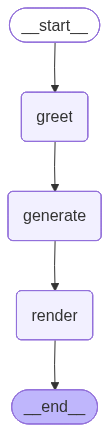

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
entry_dict= {"messages": [{"role": "user", "content": "Hello! What topic would you like me to write about for the PDF?"}]}

In [9]:
app.invoke(entry_dict)

{'document': [{'text': "Whales are majestic creatures that inhabit the world's oceans. They are mammals, breathing air and giving birth to live young, rather than laying eggs like fish.", 'font': 'Times-Roman', 'font_size': 12, 'align': 'left'}, {'text': 'There are two main categories of whales: toothed whales, such as orcas and sperm whales, and baleen whales, such as blue whales and humpback whales. Each type has unique characteristics and adaptations.', 'font': 'Times-Roman', 'font_size': 12, 'align': 'left'}, {'text': 'Whales are known for their impressive size, with the blue whale being the largest animal on Earth, reaching lengths of up to 100 feet and weighing over 200 tons. Despite their massive size, whales are incredibly agile and can swim at speeds of up to 30 miles per hour.', 'font': 'Times-Roman', 'font_size': 12, 'align': 'left'}, {'text': 'Whales play a crucial role in maintaining the health of the ocean ecosystem. They help to regulate the population of other marine an

RuntimeError: No generated_document found in state.